# Code Dump for Reference

## Initialization

First, run this cell in order for **hot_open to work**. Remember to update the path to point to the src folder of this repo. This is required because some scripts in this repo use the hot_open module (like a tool of this repo) and they need to find it. Alternatively one could pass environment variables in the launch process of this session.

Remember to re-run this cell after each restart of the kernel or session.

In [ ]:
import sys; sys.path.insert(0, "C:/Users/ryan.feusi/hill-of-towie-open-source-analysis/src")

To test it run:

In [ ]:
import hot_open
print(hot_open.__file__)

C:\Users/ryan.feusi/OneDrive - OST/Dokumente/RES Project/hill-of-towie-open-source-analysis/src\hot_open\__init__.py


To add new modules/libraries to the dependency, use `uv add [package]` in the terminal.

## Fetching Data from Zenodo

For this we can use one of the ready-made scripts of the repo which handles this automatically:

In [ ]:
%run "./scripts/wfc_analysis_2026/inspect_data.py"

### Get Data of Turbine Models

In [ ]:
from hot_open.sourcing_data import ensure_hot_data_files
from hot_open.settings import get_data_dir
import pandas as pd

# Nur die Turbinen-Metadaten anfordern (kleine Dateien wie Reports werden automatisch mitgeladen)
ensure_hot_data_files(["Hill_of_Towie_turbine_metadata.csv"])

data_dir = get_data_dir()
turbine_metadata = pd.read_csv(data_dir / "Hill_of_Towie_turbine_metadata.csv")
turbine_metadata

### Transforming Location Data from absolute coordinates to x,y relative meters

In [ ]:
from pyproj import Transformer

# WGS84 (Lat/Lon in Grad) -> UTM Zone 30N (Meter) - passt für Schottland/Hill of Towie
transformer = Transformer.from_crs("EPSG:4326", "EPSG:32630", always_xy=True)

lon = turbine_metadata["Longitude"].to_numpy()
lat = turbine_metadata["Latitude"].to_numpy()
utm_x, utm_y = transformer.transform(lon, lat)

# Ursprung auf die Ecke des Windparks legen -> kleinere, handlichere Zahlen
x = utm_x - utm_x.min()
y = utm_y - utm_y.min()

### Get SCADA Data of T01

In [ ]:
import pandas as pd
from hot_open.settings import get_data_dir
from hot_open.scada_helpers import load_hot_10min_data

start = pd.Timestamp("2026-02-20 00:00", tz="UTC")
end_excl = pd.Timestamp("2026-02-20 04:30", tz="UTC")   # bis und ohne -> letzter Zeitstempel 04:20

scada = load_hot_10min_data(
    data_dir=get_data_dir(),
    wtg_numbers=range(1, 22),    # alle 21 Turbinen, für vergleich später
    start_dt=start,
    end_dt_excl=end_excl,
)

scada["T01"][["wtc_AcWindSp_mean", "wtc_NacelPos_mean", "wtc_ActPower_mean"]]

### Creating generic wind turbines

In [ ]:
from py_wake.wind_turbines.generic_wind_turbines import GenericWindTurbine

rated_power_kw = turbine_metadata["Rated power (kW)"].iloc[0]    # 2300 kW
rotor_diameter = turbine_metadata["Rotor Diameter (m)"].iloc[0]  # 82 m
hub_height = turbine_metadata["Hub Height (m)"].iloc[0]          # 59 m

swt23 = GenericWindTurbine(
    name="SWT-2.3-VS-82",
    diameter=rotor_diameter,
    hub_height=hub_height,
    power_norm=rated_power_kw,
    turbulence_intensity=0.1,
)

##### Test

print(x)
print(y)
print(swt23)
print(swt23.diameter(), swt23.hub_height())

### Yaw Example

c:\Users\ryan.feusi\hill-of-towie-open-source-analysis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


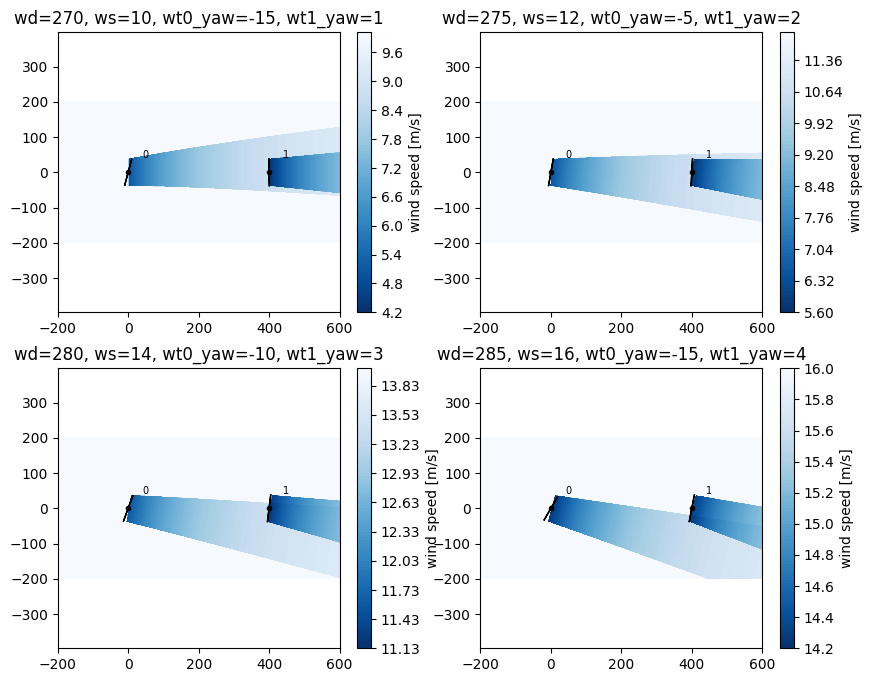

In [1]:
import matplotlib.pyplot as plt
from py_wake.deficit_models.noj import NOJ
from py_wake.site._site import UniformSite
from py_wake.examples.data.hornsrev1 import V80
from py_wake.deflection_models.jimenez import JimenezWakeDeflection
wfm = NOJ(UniformSite(), V80(), deflectionModel=JimenezWakeDeflection())

wd = [270, 275, 280, 285]
ws = [10, 12, 14, 16]
yaw = [[-15, -5, -10, -15], [1, 2, 3, 4]]
sim_res = wfm(x=[0, 400], y=[0, 0], wd=wd, ws=ws, yaw=yaw, tilt=0, time=True)

for i, ax in enumerate(plt.subplots(2, 2, figsize=(10, 8))[1].flatten()):
    sim_res.flow_map(time=i).plot_wake_map(ax=ax)
    ax.set_title(f'wd={wd[i]}, ws={ws[i]}, wt0_yaw={yaw[0][i]}, wt1_yaw={yaw[1][i]}')
plt.show()